# **Problem Statemen**t

In this project ,we are going to analyze COVID-19 data to understand how the number of confirmed ,recovered and Deaths cases changed over time .We will also visualize the trends and finally predict future cases using Time Series Forecasting .

In [65]:

import numpy as  np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
df=pd.read_csv('/content/Covid_19_Clean_Complete.csv')



In [67]:
df


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [68]:
df.head(10)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa
5,NaN,Antigua and Barbuda,17.06080,-61.796400,2020-01-22,0,0,0,0,Americas
6,NaN,Argentina,-38.41610,-63.616700,2020-01-22,0,0,0,0,Americas
7,NaN,Armenia,40.06910,45.038200,2020-01-22,0,0,0,0,Europe
8,Australian Capital Territory,Australia,-35.47350,149.012400,2020-01-22,0,0,0,0,Western Pacific
9,New South Wales,Australia,-33.86880,151.209300,2020-01-22,0,0,0,0,Western Pacific


In [69]:
df.tail(10)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
49058,NaN,Malawi,-13.254300,34.301500,2020-07-27,3664,99,1645,1920,Africa
49059,Falkland Islands (Malvinas),United Kingdom,-51.796300,-59.523600,2020-07-27,13,0,13,0,Europe
49060,Saint Pierre and Miquelon,France,46.885200,-56.315900,2020-07-27,4,0,1,3,Europe
49061,NaN,South Sudan,6.877000,31.307000,2020-07-27,2305,46,1175,1084,Africa
49062,NaN,Western Sahara,24.215500,-12.885800,2020-07-27,10,1,8,1,Africa
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe
49067,NaN,Lesotho,-29.610000,28.233600,2020-07-27,505,12,128,365,Africa


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [71]:
df.shape

(49068, 10)

In [72]:
# Rename the correct column name
df.rename(columns={'Province/State':'State','Country/Region':'Country'},inplace=True)


In [73]:
df

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [74]:
df['Date'].value_counts()

,count
Date,
2020-01-22,261
2020-01-23,261
2020-01-24,261
2020-01-25,261
2020-01-26,261
...,...
2020-07-23,261
2020-07-24,261
2020-07-25,261


In [75]:
# Latest Date
df['Date'].max()

'2020-07-27'

In [76]:
# Populating rows with the max Date
top=df[df['Date']=='2020-07-27']
top

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48807,NaN,Afghanistan,33.939110,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean
48808,NaN,Albania,41.153300,20.168300,2020-07-27,4880,144,2745,1991,Europe
48809,NaN,Algeria,28.033900,1.659600,2020-07-27,27973,1163,18837,7973,Africa
48810,NaN,Andorra,42.506300,1.521800,2020-07-27,907,52,803,52,Europe
48811,NaN,Angola,-11.202700,17.873900,2020-07-27,950,41,242,667,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [77]:
# Group the column based on the country
# What is the total confirmed, recovered , deaths and active cases of all the country
top.groupby('Country')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
top

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48807,NaN,Afghanistan,33.939110,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean
48808,NaN,Albania,41.153300,20.168300,2020-07-27,4880,144,2745,1991,Europe
48809,NaN,Algeria,28.033900,1.659600,2020-07-27,27973,1163,18837,7973,Africa
48810,NaN,Andorra,42.506300,1.521800,2020-07-27,907,52,803,52,Europe
48811,NaN,Angola,-11.202700,17.873900,2020-07-27,950,41,242,667,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [78]:
# Populating all confirmed cases in the confirmed df
confirmed=df.groupby('Date')['Confirmed'].sum().reset_index()
confirmed

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


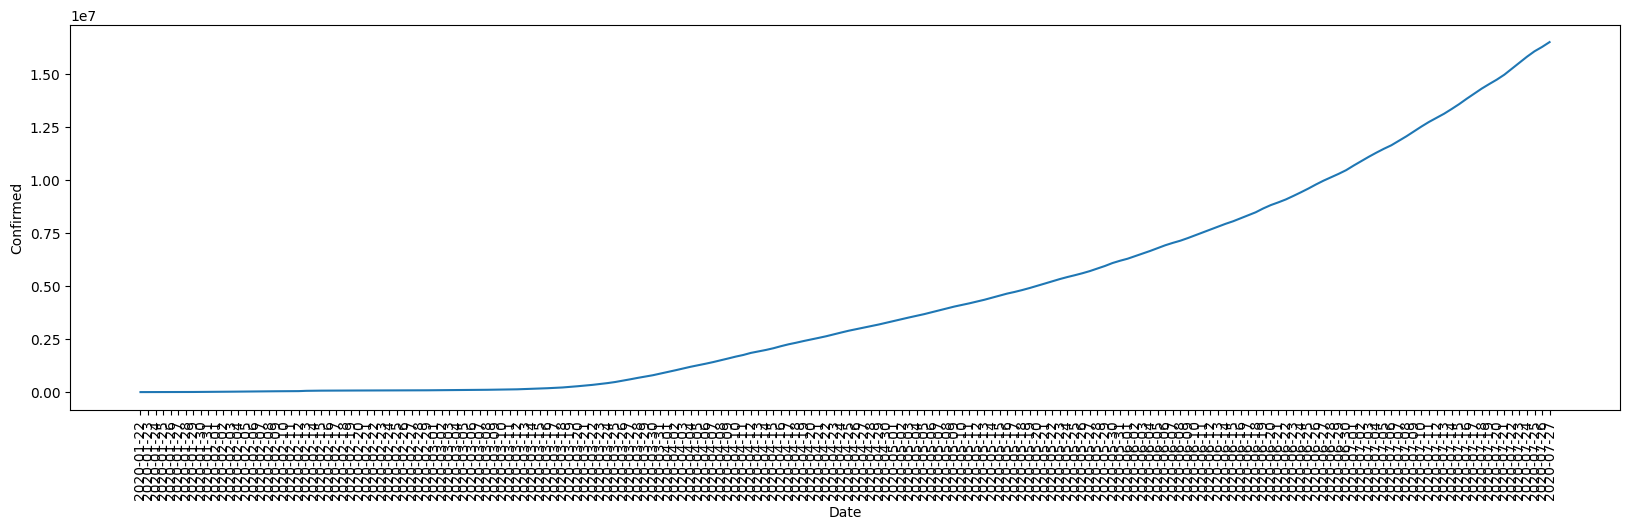

In [79]:
# Visuilizing the confirmed cases
plt.figure(figsize=(20,5))
sns.lineplot( data =confirmed,x='Date',y='Confirmed')
plt.xticks(rotation=90)
plt.show()

In [80]:
recovered=df.groupby('Date')['Recovered'].sum().reset_index()
recovered

,Date,Recovered
0,2020-01-22,28
1,2020-01-23,30
2,2020-01-24,36
3,2020-01-25,39
4,2020-01-26,52
...,...,...
183,2020-07-23,8710969
184,2020-07-24,8939705
185,2020-07-25,9158743
186,2020-07-26,9293464


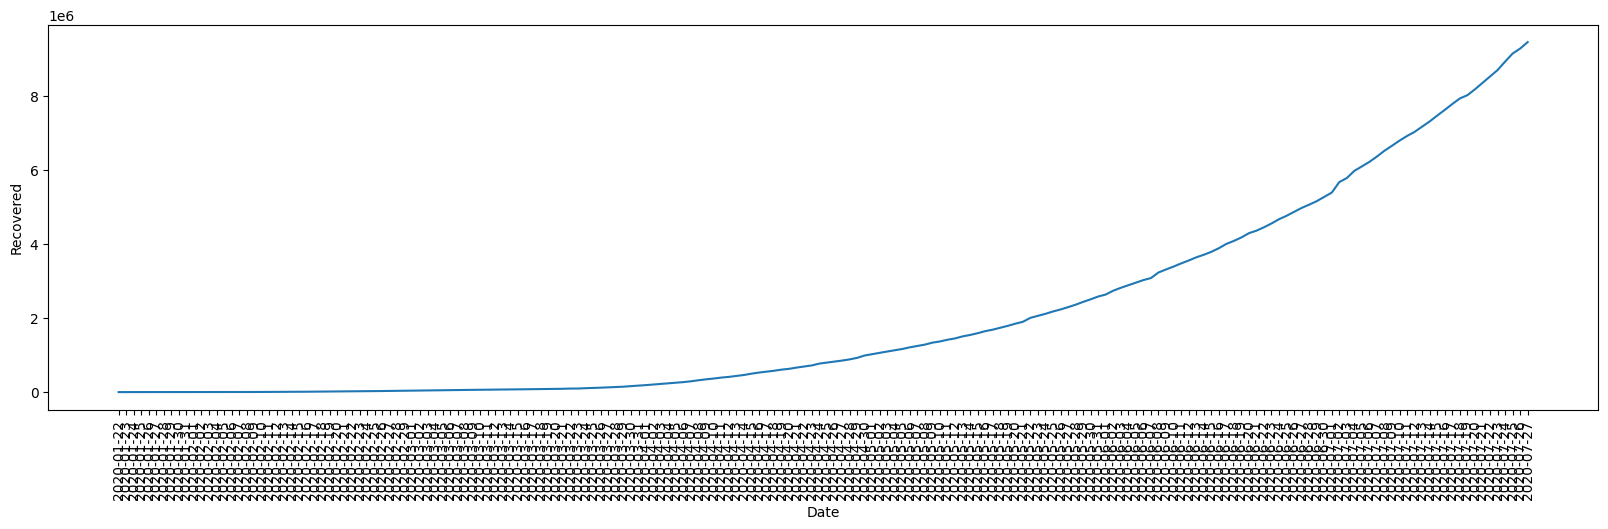

In [81]:
plt.figure(figsize=(20,5))
sns.lineplot(data=recovered,x='Date',y='Recovered')
plt.xticks(rotation=90)
plt.show()

In [82]:
 # Top 10 Countries with most  Recovered Cases
 top_10_recovered =df.groupby('Country')['Recovered'].sum().sort_values(ascending=False).head(10).reset_index()
top_10_recovered

,Country,Recovered
0,US,56353416
1,Brazil,54492873
2,Russia,25120448
3,India,23783720
4,Germany,17107839
5,Italy,15673910
6,Iran,15200895
7,Spain,15093583
8,Turkey,13345389
9,Chile,13292593


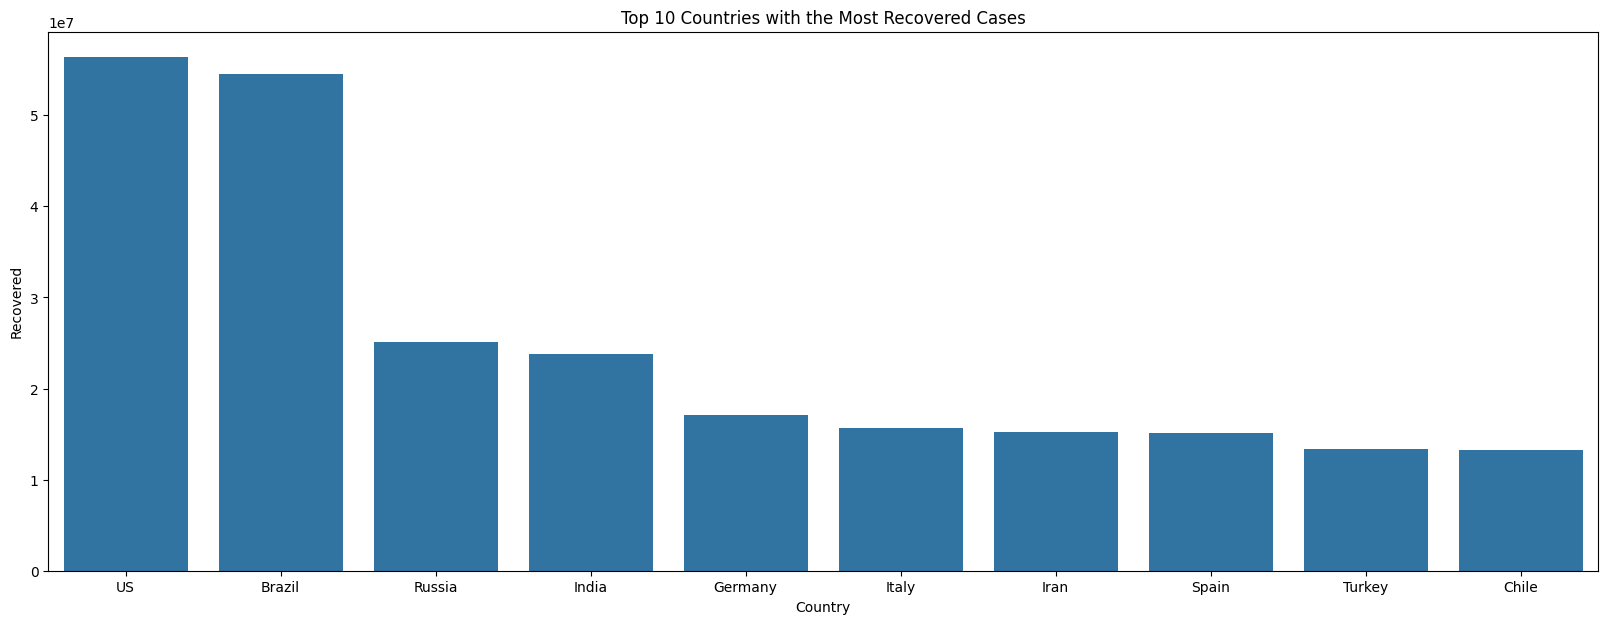

In [83]:
#Visualising the top 10 recovered cases
plt.figure(figsize=(20,7))
sns.barplot(data=top_10_recovered,x='Country',y='Recovered')
plt.title('Top 10 Countries with the Most Recovered Cases')
plt.show()

In [84]:
# Top 10 Countries with most Deaths Cases
top_10_deaths =df.groupby('Country')['Deaths'].sum().sort_values(ascending=False).head(10).reset_index()
top_10_deaths

,Country,Deaths
0,US,11011411
1,United Kingdom,3997775
2,Brazil,3938034
3,Italy,3707717
4,France,3048524
5,Spain,3033030
6,Mexico,1728277
7,India,1111831
8,Iran,1024136
9,Belgium,963679


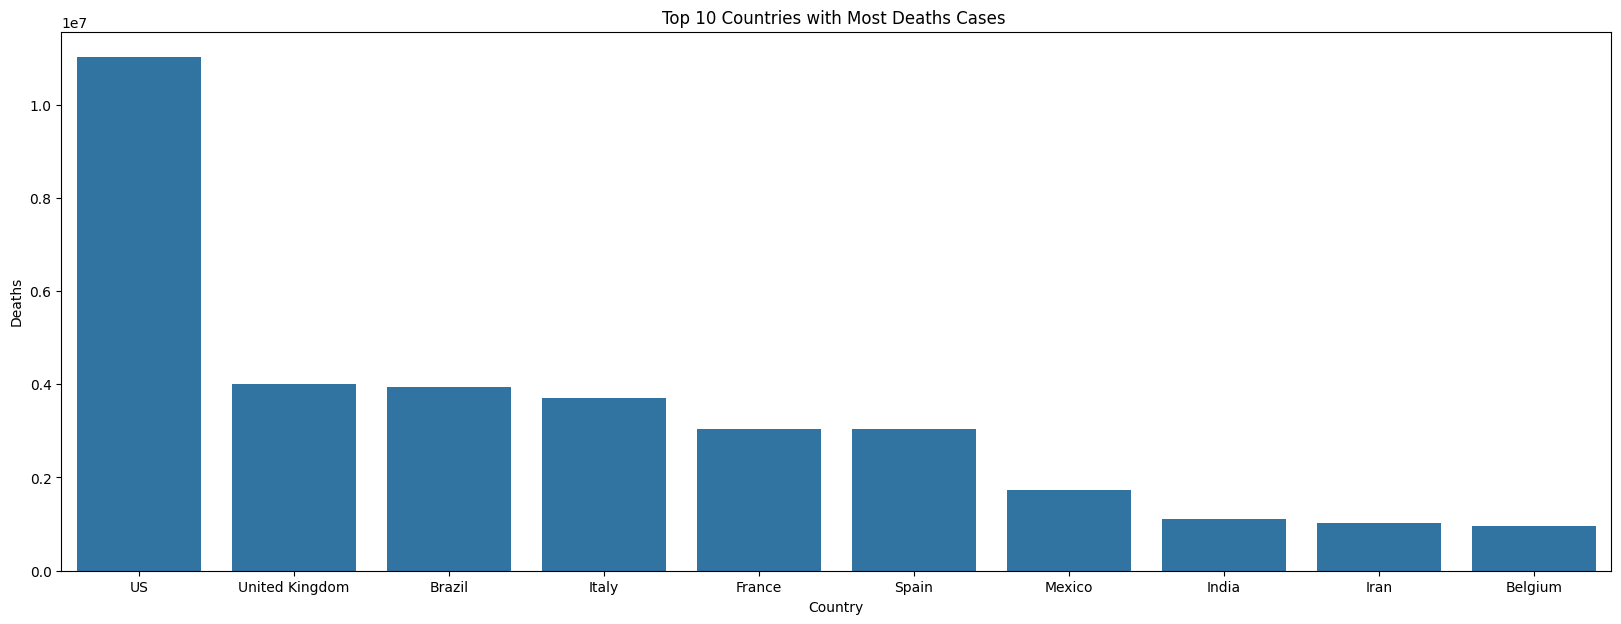

In [85]:
# Visualizing the top 10 Deaths Cases
plt.figure(figsize=(20,7))
sns.barplot(data=top_10_deaths,x='Country',y='Deaths')
plt.title('Top 10 Countries with Most Deaths Cases ')
plt.show()



Country Based Analysis

US
India
China





In [86]:
# Create the US Datasets
US=df[df['Country']=='US']
US

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
223,NaN,US,40.0,-100.0,2020-01-22,1,0,0,1,Americas
484,NaN,US,40.0,-100.0,2020-01-23,1,0,0,1,Americas
745,NaN,US,40.0,-100.0,2020-01-24,2,0,0,2,Americas
1006,NaN,US,40.0,-100.0,2020-01-25,2,0,0,2,Americas
1267,NaN,US,40.0,-100.0,2020-01-26,5,0,0,5,Americas
...,...,...,...,...,...,...,...,...,...,...
47986,NaN,US,40.0,-100.0,2020-07-23,4038816,144430,1233269,2661117,Americas
48247,NaN,US,40.0,-100.0,2020-07-24,4112531,145560,1261624,2705347,Americas
48508,NaN,US,40.0,-100.0,2020-07-25,4178970,146465,1279414,2753091,Americas
48769,NaN,US,40.0,-100.0,2020-07-26,4233923,146935,1297863,2789125,Americas


In [87]:
US=US.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
US

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,1,0,0,1
1,2020-01-23,1,0,0,1
2,2020-01-24,2,0,0,2
3,2020-01-25,2,0,0,2
4,2020-01-26,5,0,0,5
...,...,...,...,...,...
183,2020-07-23,4038816,144430,1233269,2661117
184,2020-07-24,4112531,145560,1261624,2705347
185,2020-07-25,4178970,146465,1279414,2753091
186,2020-07-26,4233923,146935,1297863,2789125


In [88]:
# Create the Datasets for India
India=df[df['Country']=='India']
India

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
129,NaN,India,20.593684,78.96288,2020-01-22,0,0,0,0,South-East Asia
390,NaN,India,20.593684,78.96288,2020-01-23,0,0,0,0,South-East Asia
651,NaN,India,20.593684,78.96288,2020-01-24,0,0,0,0,South-East Asia
912,NaN,India,20.593684,78.96288,2020-01-25,0,0,0,0,South-East Asia
1173,NaN,India,20.593684,78.96288,2020-01-26,0,0,0,0,South-East Asia
...,...,...,...,...,...,...,...,...,...,...
47892,NaN,India,20.593684,78.96288,2020-07-23,1288108,30601,817209,440298,South-East Asia
48153,NaN,India,20.593684,78.96288,2020-07-24,1337024,31358,849432,456234,South-East Asia
48414,NaN,India,20.593684,78.96288,2020-07-25,1385635,32060,885573,468002,South-East Asia
48675,NaN,India,20.593684,78.96288,2020-07-26,1435616,32771,917568,485277,South-East Asia


In [89]:
India=India.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
India

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,1288108,30601,817209,440298
184,2020-07-24,1337024,31358,849432,456234
185,2020-07-25,1385635,32060,885573,468002
186,2020-07-26,1435616,32771,917568,485277


In [90]:
# Create the Datasets for China
China=df[df['Country']=='China']
China

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48,Anhui,China,31.8257,117.2264,2020-01-22,1,0,0,1,Western Pacific
49,Beijing,China,40.1824,116.4142,2020-01-22,14,0,0,14,Western Pacific
50,Chongqing,China,30.0572,107.8740,2020-01-22,6,0,0,6,Western Pacific
51,Fujian,China,26.0789,117.9874,2020-01-22,1,0,0,1,Western Pacific
52,Gansu,China,35.7518,104.2861,2020-01-22,0,0,0,0,Western Pacific
...,...,...,...,...,...,...,...,...,...,...
48883,Tianjin,China,39.3054,117.3230,2020-07-27,204,3,195,6,Western Pacific
48884,Tibet,China,31.6927,88.0924,2020-07-27,1,0,1,0,Western Pacific
48885,Xinjiang,China,41.1129,85.2401,2020-07-27,311,3,73,235,Western Pacific
48886,Yunnan,China,24.9740,101.4870,2020-07-27,190,2,186,2,Western Pacific


In [91]:
China=China.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
China

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,548,17,28,503
1,2020-01-23,643,18,30,595
2,2020-01-24,920,26,36,858
3,2020-01-25,1406,42,39,1325
4,2020-01-26,2075,56,49,1970
...,...,...,...,...,...
183,2020-07-23,86045,4649,78701,2695
184,2020-07-24,86202,4650,78745,2807
185,2020-07-25,86381,4652,78813,2916
186,2020-07-26,86570,4652,78862,3056


Compare these Countries on the basis for their Recovered Cases


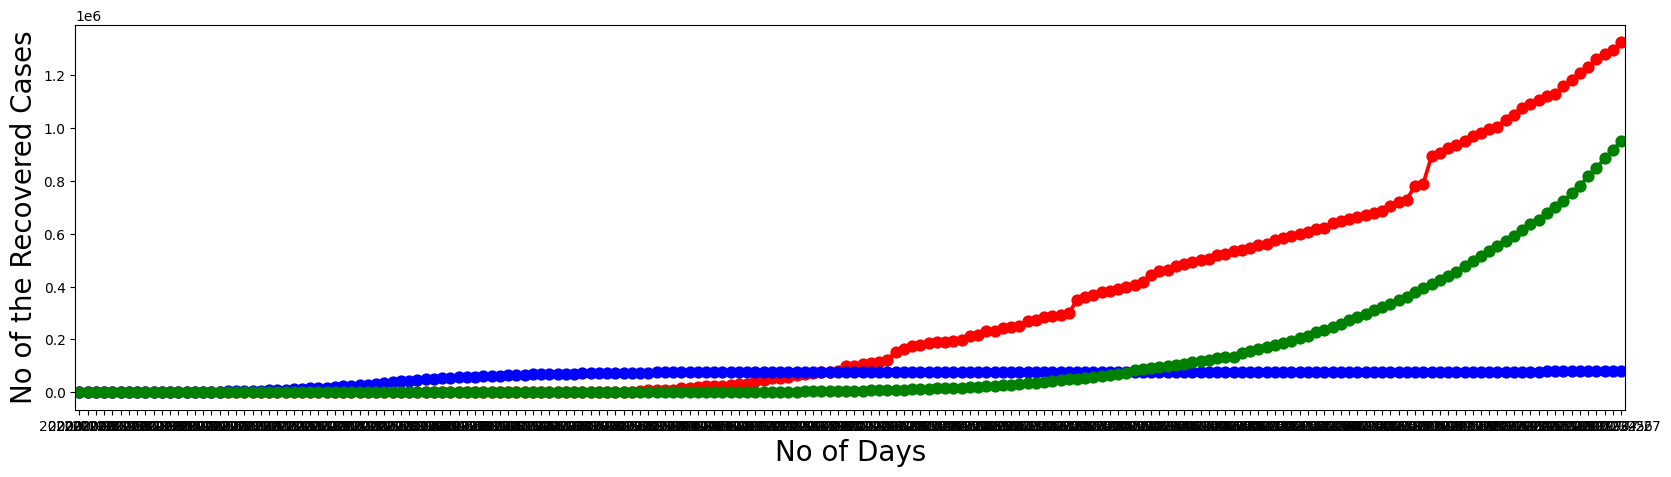

In [92]:
# Visualize using pointplot
plt.figure(figsize=(20,5))
sns.pointplot(data=US,x='Date',y='Recovered',color='Red')
sns.pointplot(data=China,x='Date',y='Recovered',color='Blue')
sns.pointplot(data=India,x='Date',y='Recovered',color='Green')

plt.xlabel('No of Days',fontsize=20)
plt.ylabel('No of the Recovered Cases',fontsize=20)

plt.show()

Compare these Countries on the basis of their Deaths Cases

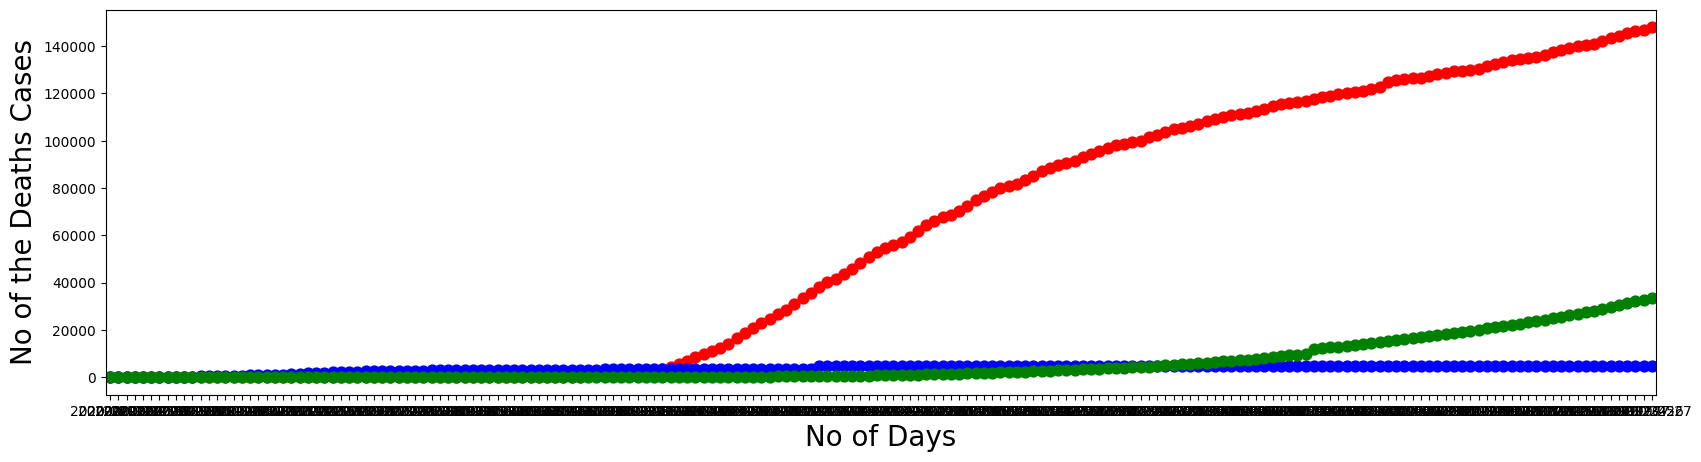

In [93]:
# Visualize using pointplot
plt.figure(figsize=(20,5))
sns.pointplot(data=US,x='Date',y='Deaths',color='Red')
sns.pointplot(data=China,x='Date',y='Deaths',color='Blue')
sns.pointplot(data=India,x='Date',y='Deaths',color='Green')

plt.xlabel('No of Days',fontsize=20)
plt.ylabel('No of the Deaths Cases',fontsize=20)

plt.show()

Model Building

In [94]:
# Installing Prophet
!pip install prophet

In [95]:
# Reading the Dataset
df=pd.read_csv('/content/Covid_19_Clean_Complete.csv',parse_dates=['Date'])
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  14664 non-null  object        
 1   Country/Region  49068 non-null  object        
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[ns]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


In [97]:
# Create a new Dataset of confirmed cases
confirmed=df.groupby('Date')['Confirmed'].sum().reset_index()
confirmed

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [98]:
# Create a new Dataset of Deaths cases
Deaths=df.groupby('Date')['Deaths'].sum().reset_index()
Deaths

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


In [99]:
# Create a new Dataset of Active Cases
active=df.groupby('Date')['Active'].sum().reset_index()
active

,Date,Active
0,2020-01-22,510
1,2020-01-23,606
2,2020-01-24,879
3,2020-01-25,1353
4,2020-01-26,2010
...,...,...
183,2020-07-23,6166006
184,2020-07-24,6212290
185,2020-07-25,6243930
186,2020-07-26,6309711


In [100]:
# Create a new Datasets of Recovered cases
Recovered=df.groupby('Date')['Recovered'].sum().reset_index()
Recovered

,Date,Recovered
0,2020-01-22,28
1,2020-01-23,30
2,2020-01-24,36
3,2020-01-25,39
4,2020-01-26,52
...,...,...
183,2020-07-23,8710969
184,2020-07-24,8939705
185,2020-07-25,9158743
186,2020-07-26,9293464


Forecasting The Confirmed Cases

In [101]:
# Renaming the columns to ds and y
confirmed.columns=['ds','y']

In [102]:
confirmed

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [103]:
# Importing the prophet library
from prophet import Prophet

In [104]:
model=Prophet()

In [105]:
model.fit(confirmed)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [106]:
# Make predictions for 7 Days
future=model.make_future_dataframe(periods=7)
forecast=model.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-1.035916e+04,-1.294412e+05,9.018620e+04,-1.035916e+04,-1.035916e+04,-11045.230807,-11045.230807,-11045.230807,-11045.230807,-11045.230807,-11045.230807,0.0,0.0,0.0,-2.140439e+04
1,2020-01-23,-7.617091e+03,-1.188212e+05,9.128087e+04,-7.617091e+03,-7.617091e+03,-1109.169058,-1109.169058,-1109.169058,-1109.169058,-1109.169058,-1109.169058,0.0,0.0,0.0,-8.726260e+03
2,2020-01-24,-4.875024e+03,-9.274732e+04,1.157763e+05,-4.875024e+03,-4.875024e+03,10132.112117,10132.112117,10132.112117,10132.112117,10132.112117,10132.112117,0.0,0.0,0.0,5.257088e+03
3,2020-01-25,-2.132956e+03,-8.541552e+04,1.193618e+05,-2.132956e+03,-2.132956e+03,13751.834873,13751.834873,13751.834873,13751.834873,13751.834873,13751.834873,0.0,0.0,0.0,1.161888e+04
4,2020-01-26,6.091115e+02,-9.613954e+04,1.138852e+05,6.091115e+02,6.091115e+02,7254.714658,7254.714658,7254.714658,7254.714658,7254.714658,7254.714658,0.0,0.0,0.0,7.863826e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,1.674494e+07,1.664361e+07,1.684369e+07,1.674199e+07,1.674975e+07,-1109.169058,-1109.169058,-1109.169058,-1109.169058,-1109.169058,-1109.169058,0.0,0.0,0.0,1.674383e+07
191,2020-07-31,1.694894e+07,1.685013e+07,1.706396e+07,1.694181e+07,1.695875e+07,10132.112117,10132.112117,10132.112117,10132.112117,10132.112117,10132.112117,0.0,0.0,0.0,1.695907e+07
192,2020-08-01,1.715294e+07,1.706046e+07,1.727852e+07,1.713864e+07,1.716993e+07,13751.834873,13751.834873,13751.834873,13751.834873,13751.834873,13751.834873,0.0,0.0,0.0,1.716669e+07
193,2020-08-02,1.735694e+07,1.724999e+07,1.746435e+07,1.733188e+07,1.738160e+07,7254.714658,7254.714658,7254.714658,7254.714658,7254.714658,7254.714658,0.0,0.0,0.0,1.736419e+07


ds:This is the Date column.
yhat:This is the predicted value.
yhat lower & yhat upper:
Predicted Range
yhat_lower-> Minimum expected value
yhat_upper-> Maximum expected **value**



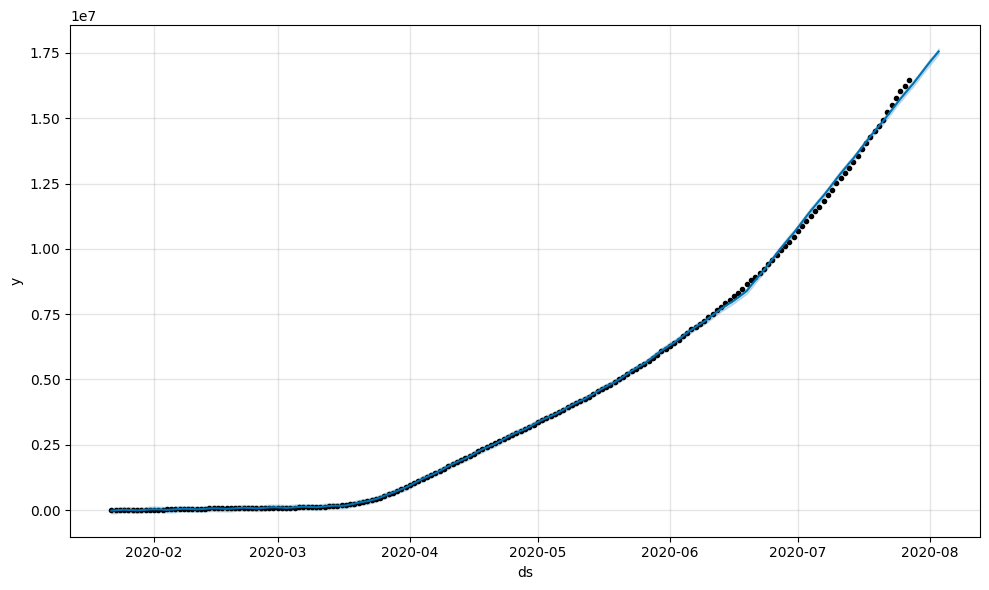

In [107]:
# Visualize the forecast
model.plot(forecast)
plt.show()

In [108]:
# Importing the plotly library
import plotly
import plotly.express as px



In [109]:
world=df.groupby('Country/Region')[['Confirmed','Deaths','Active','Recovered']].sum().reset_index()

In [110]:
world

,Country/Region,Confirmed,Deaths,Active,Recovered
0,Afghanistan,1936390,49098,1089052,798240
1,Albania,196702,5708,72117,118877
2,Algeria,1179755,77972,345886,755897
3,Andorra,94404,5423,19907,69074
4,Angola,22662,1078,15011,6573
...,...,...,...,...,...
182,West Bank and Gaza,233461,1370,170967,61124
183,Western Sahara,901,63,190,648
184,Yemen,67180,17707,25694,23779
185,Zambia,129421,2643,43167,83611


In [111]:
figure=px.choropleth(world,locations='Country/Region',locationmode='country names',color='Active',hover_name='Country/Region',range_color=[1,20000],color_continuous_scale='reds',title='Countries with Active Cases')
figure.show()